
### Hydrogen System modelling
Hydrogen has been extensively explored in the past few years for its potential in clean energy applications/Hydrogen based technologies have gained growing interest in the renewable energy sector for a few years. This tutorial is going to explore a few case studies that focus on the use of hydrogen technologies to get familiar with handling hydrogen systems and models in the illuminator. 

But, first of all, what role do Hydrogen technologies play in a renewable future?
There are three important aspects that make hydrogen a interesting subject
- hydrogen as a fuel is very energy dense
- hydrogen can be stored mechanically for long periods of time
- hydrogen combustion (and conversion) has water as only by-product, therefore Hydrogen based fuel cells and boilers do not emit GHG'

Hydrogen solutions are therefore very attractive for energy intensive sectors that currently produce high amounts of green house gasses (GHG's) also know has hard-to-abate sectors, and long term storage applications. A quick online search will reveal that heavy industries (petrochemical industries along with industries producing iron and steel) are the most promising applications, these two industries alone are responsible for approximately 10% of the global total GHG's emissions, while hydrogen combustion can achieve the required high temperatures without direct carbon emissions.


In this tutorial we explore how to transition 5 industrial chemical plants from fossil fuel based utility systems to renewable based utility systems with the help of hydrogen. This should also give you an insight into how to use and integrate the Illuminator's hydrogen models into your simulations. 

-> paper assumes all non fossil fuel technology to be 0 CO2 emission
-> paper takes historic prices from day ahead market
-> paper identifies optimal solution as cheapest 

-> paper doesn't account for energy mix CO2

## 1. (OBSERVE) CURRENT CASE
Let's start by looking at how the plants operate when using fossil fuels as power source, we can call these legacy technologies as we mean to replace these with more sustainable ones.

- show heat and electricity demand from 5 plants and energy
- show cost of operation and electricity
- show CO2 production 

MODELS
input 
-> load 
-> heat load (same as load)
into
-> utility tech model (?)
out 
-> cost
-> co2

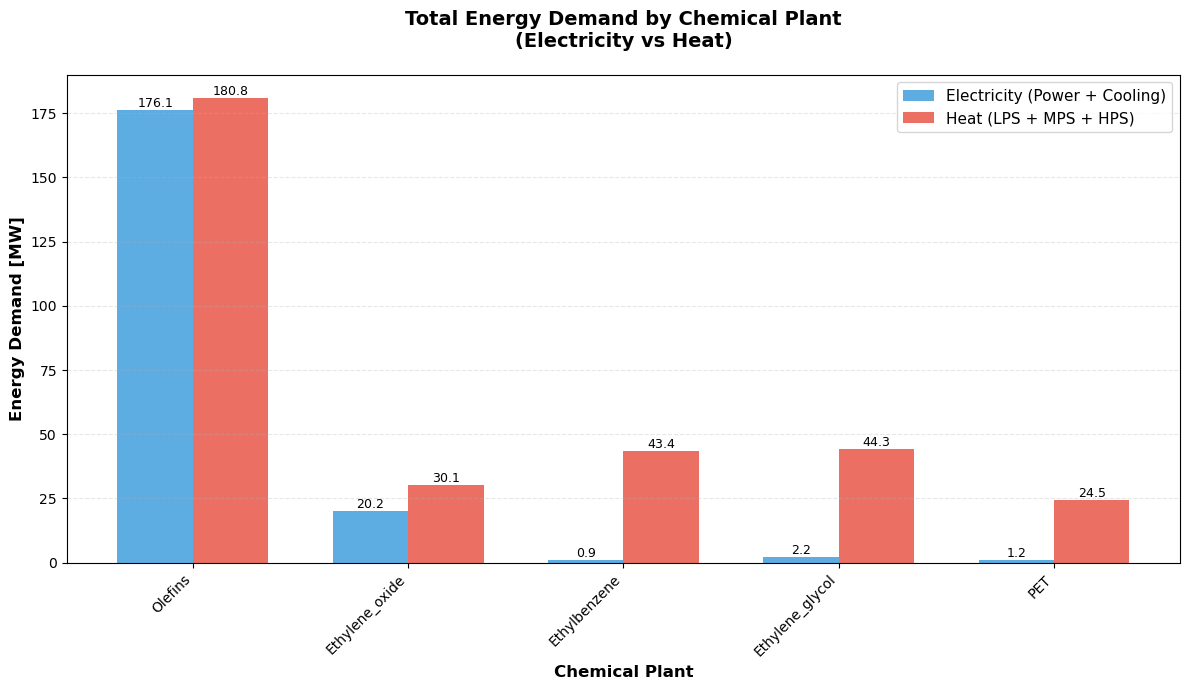

In [1]:
from plot_chemical_plants import plot_chemical_plants_demand
import matplotlib.pyplot as plt

# Simple call just displays the plot
fig, ax = plot_chemical_plants_demand('data/chemical_plants_data.csv')
plt.show()

We assume to use CHP for plants with similar heat and power demand and gas boilers for plants with a predominant heat demand. For 2023 the average market price of electricity is 98 euro/MWh, the average gas-energy price is 59 euro/MWh. The average CO2 released per MWh is ...kg. With constant demand for all plants the KPIs of the current technology are:

In [2]:
import pandas as pd

df = pd.read_csv('data/chemical_plants_data.csv')  # Use forward slash
columns_to_sum = ['Power_MW', 'Cooling_MW', 'LPS_MW', 'MPS_MW', 'HPS_MW']
total = df[columns_to_sum].sum().sum()

CO2 = pd.read_csv('data/co2_emissions_per_plant.csv')
total_co2_legacy = CO2['CO2_Emissions_kton_per_year'].sum()

total_price=59+98 # $/MWh

power_mw = total  # MW (peak or installed capacity)
hours_per_year = 8760

energy_mwh_per_year_legacy = power_mw * hours_per_year
total_yearly_costs_legacy = energy_mwh_per_year_legacy * total_price

print(f"Total Yearly Costs: {total_yearly_costs_legacy:.2f} euros/year")
print(f"Total CO2 Emissions: {total_co2_legacy:.2f} Kton/year")


Total Yearly Costs: 720213824.40 euros/year
Total CO2 Emissions: 993.20 Kton/year


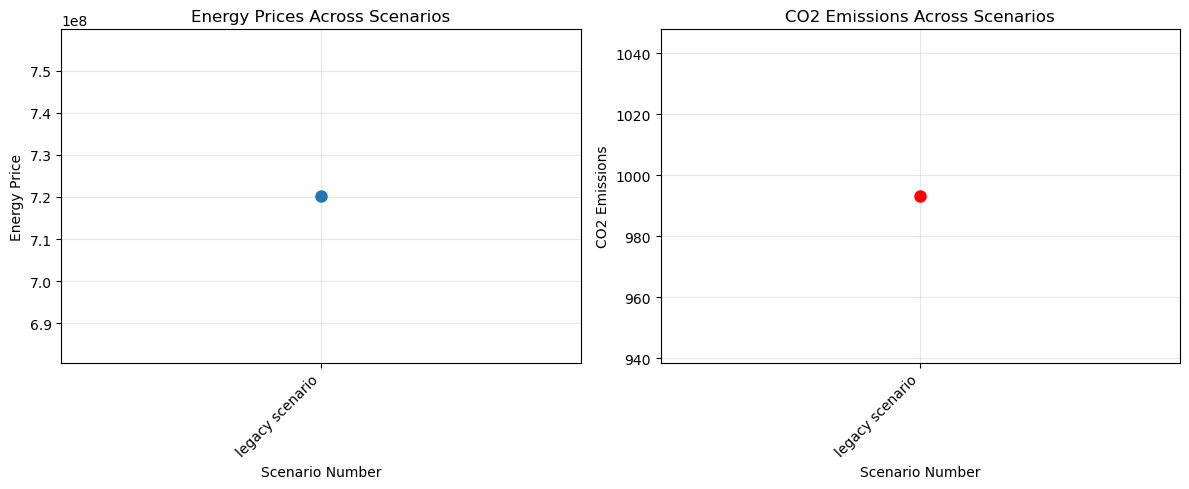

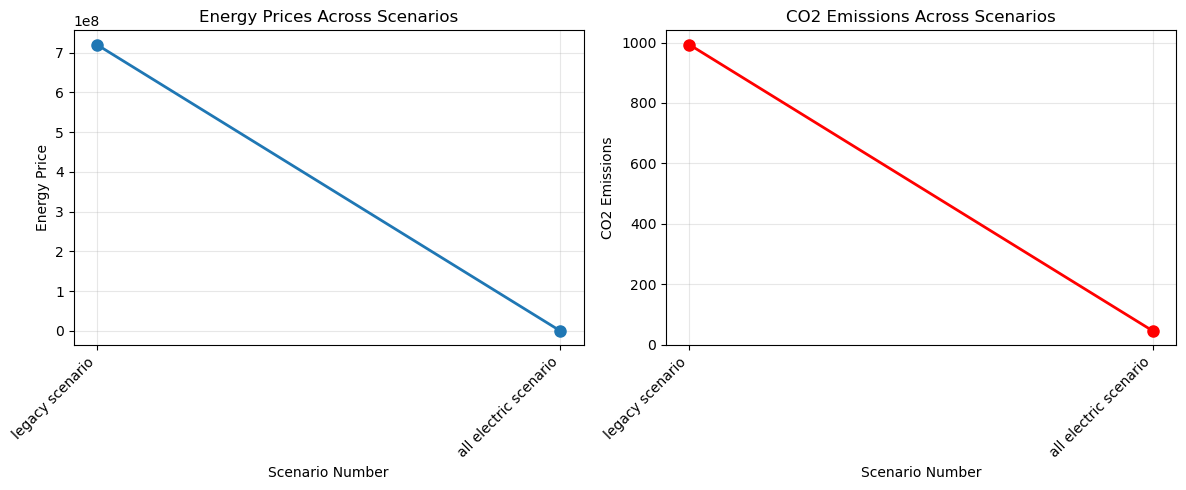

In [3]:
# In your notebook
from plot_chemical_plants import ScenarioPlotter

# Create plotter instance once
plotter = ScenarioPlotter()

# Call after each scenario
plotter.add_and_plot(total_yearly_costs_legacy, total_co2_legacy, "legacy scenario")
plotter.add_and_plot(120, 45, "all electric scenario")
#plotter.add_and_plot(110, 48, "energy mix scenario")
#plotter.add_and_plot(110, 48, "H2 scenario")

# If you want to reset for a new set of scenarios:
# plotter.reset()

## 2. (OBSERVE) SHIFT TO ELECTRIC BOILERS 

Now we make a shift to electricity powered boilers and evaluate the effect on CO2 emissions and cost:
Since the electric boilers create heat from electricity the demand of the plants shifts to only electric

- show electricity demand (no heat if all electricity) and energy, does it change
- show cost of operation and electricity (lower) 
- show CO2 production (lower) 

## 2b. (INTERVENE) CHANGE ENERGY MIX 
We can see that choosing electric boilers really only shifts the CO2 problem to the electricity generation. (although it is more efficient)

- vary percentage of renewable energy 
- show CO2 production (higher than before) taking into consideration energy mix (use annual average CO2 factor)
- cost of operation and electricity

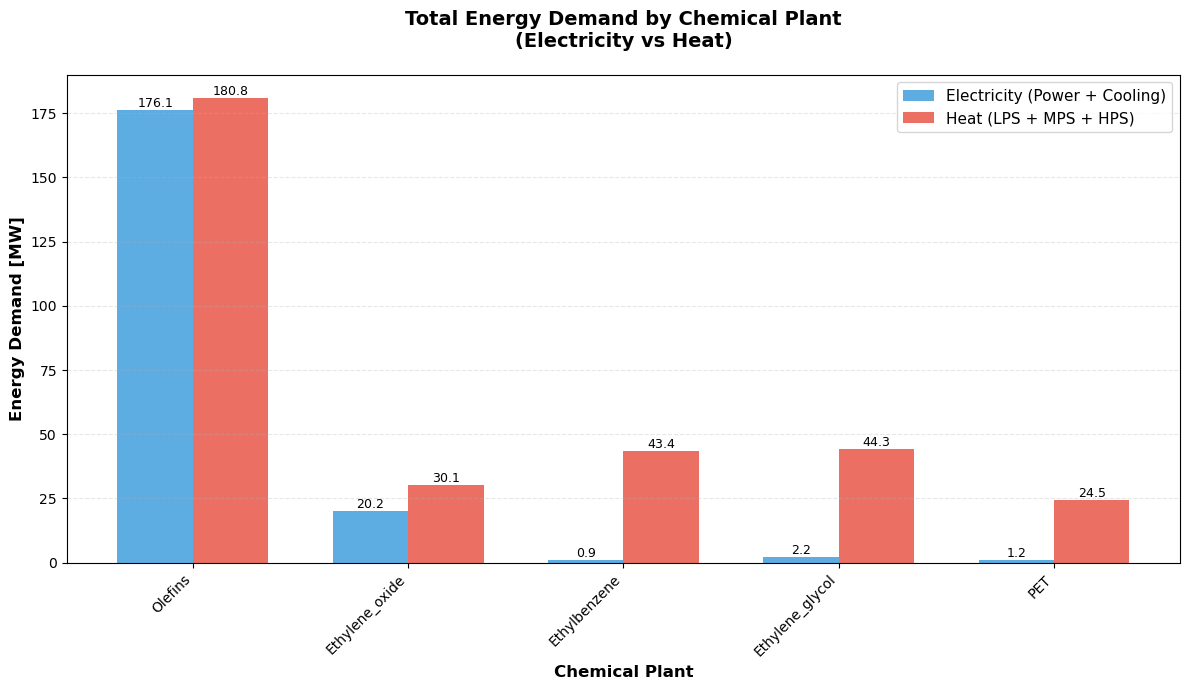

In [4]:
from plot_chemical_plants import plot_chemical_plants_demand
import matplotlib.pyplot as plt

# Simple call - just displays the plot
fig, ax = plot_chemical_plants_demand('data/chemical_plants_data.csv')
plt.show()

## 3. (INTERVENE) SHIFT gradually TO H2 BOILERS

Let's try out H2 boilers since namely their emissions of CO2 should be 0.

- show heat and electricity demand from 5 plants and energy
- show CO2 production (lower)
- cost of operation and electricity

-> this should show that H2 is not economically viable but has lower CO2 depending on electricity mix 
-> start getting familiar with H2 electrolyzer model to account for electricity cost ?

## 4. (INTERACT) H2 as ENERGY BUFFER and ELECTRIC BOILER WITH 100% renewables

Finally, we try a hybrid system that harnesses the power of both H2 and electric. We switch to only electric boilers with a 100% renewables energy mix and we use the H2 to support the renewable mix with enough storage.

-> here the models from H2 can really be used most: since we create a common H2 buffer we can explore compression, transport, storage and generation models 

- assume all boilers are now electric => get demand
- assume 100% renewables in electricity but let user change mix like 2b. this will create different supply curves (demand will be scaled version of central generation/independent renewable generation)
- determine the right amount of storage 

- show CO2 production (lower)
- cost of operation and electricity

-> cost of creating big enough storage can be shown

## 5. (CREATE) 
- determine H2 transportation losses in last model (assuming X distance)
- do same exercise as tutorial but using steel furnaces (electricity doesn't reach temperatures)
- use other types of hydrogen (not green) and see effect on cost/CO2 

-> is H2 boiler model needed ????
